# Simplex Tree Approximation of a Classifier

Given any classifier, approximate its decision boundary using a **SimplexTreeClassifier**:
1. Generate a dense grid on [0,1]×[0,1]
2. Label grid points with the classifier
3. Fit a SimplexTreeClassifier on that labeled grid
4. Compare the exact classifier prediction vs. the simplex-tree approximation
5. Check non-convexity of the boundary region around a test point

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sys, os, warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from in2D.classifying.classes.simplex_tree_classifier import SimplexTreeClassifier

np.random.seed(42)

In [2]:
def make_meshgrid(x, y, h=0.01):
    xx, yy = np.meshgrid(np.arange(x.min(), x.max(), h),
                         np.arange(y.min(), y.max(), h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, xy, **params):
    Z = clf.predict(xy)
    Z = Z.reshape(xx.shape)
    return ax.contourf(xx, yy, Z, **params)

### Data Loading

Generated ../datasets/dataset_circle.npz
Dataset: 800 points, Classes: [-1.  1.]
Distribution: {-1.0: 400, 1.0: 400}
Exact classifier accuracy: 100.00%


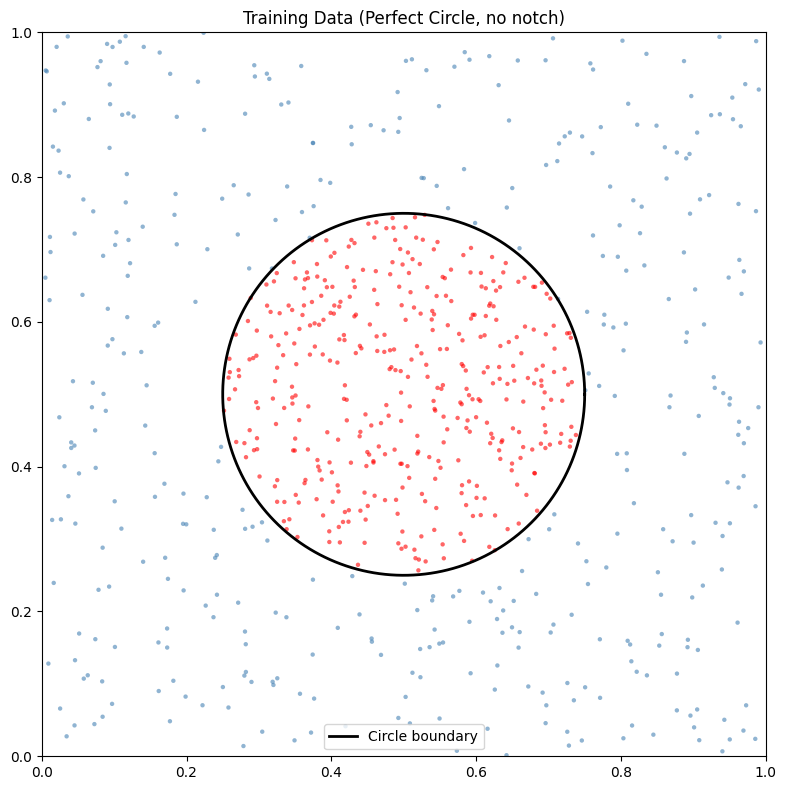

In [ ]:
CIRCLE_CENTER = np.array([0.5, 0.5])
CIRCLE_RADIUS = 0.25


def shape_classify(pts):
    pts = np.atleast_2d(pts)
    dist = np.linalg.norm(pts - CIRCLE_CENTER, axis=1)
    return np.where(dist < CIRCLE_RADIUS, 1.0, -1.0)

class ExactClassifier:
    def predict(self, pts):
        return shape_classify(pts)

    def predict_proba(self, pts):
        pts = np.atleast_2d(pts)
        dist = np.linalg.norm(pts - CIRCLE_CENTER, axis=1)
        p_inside = 1.0 / (1.0 + np.exp(50.0 * (dist - CIRCLE_RADIUS)))
        return np.column_stack([1.0 - p_inside, p_inside])

    def fit(self, X, y):
        return self

dataset_path = '../datasets/dataset_circle.npz'
REGENERATE = True

if REGENERATE or not os.path.exists(dataset_path):
    np.random.seed(42)
    n_samples = 50000
    raw_pts = np.column_stack([np.random.uniform(0, 1, n_samples),
                               np.random.uniform(0, 1, n_samples)])
    raw_labels = shape_classify(raw_pts)
    inside_idx = np.where(raw_labels == 1.0)[0]
    outside_idx = np.where(raw_labels == -1.0)[0]
    n_min = min(len(inside_idx), len(outside_idx), 400)
    keep = np.concatenate([inside_idx[:n_min], outside_idx[:n_min]])
    np.random.shuffle(keep)
    np.savez(dataset_path, X=raw_pts[keep], y=raw_labels[keep])
    print(f"Generated {dataset_path}")

data = np.load(dataset_path)
X, y = data['X'], data['y']

clf = ExactClassifier()
print(f"Dataset: {X.shape[0]} points, Classes: {np.unique(y)}")
print(f"Distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Exact classifier accuracy: {accuracy_score(y, clf.predict(X)):.2%}")

theta = np.linspace(0.0, 2.0 * np.pi, 200)
circle_xy = np.column_stack([CIRCLE_CENTER[0] + CIRCLE_RADIUS * np.cos(theta),
                             CIRCLE_CENTER[1] + CIRCLE_RADIUS * np.sin(theta)])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1],
           c=['red' if l == 1 else 'steelblue' for l in y],
           s=10, alpha=0.6, edgecolors='none')
ax.plot(circle_xy[:, 0], circle_xy[:, 1], 'k-', linewidth=2, label='Circle boundary')
ax.set_title('Training Data (Perfect Circle, no notch)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()


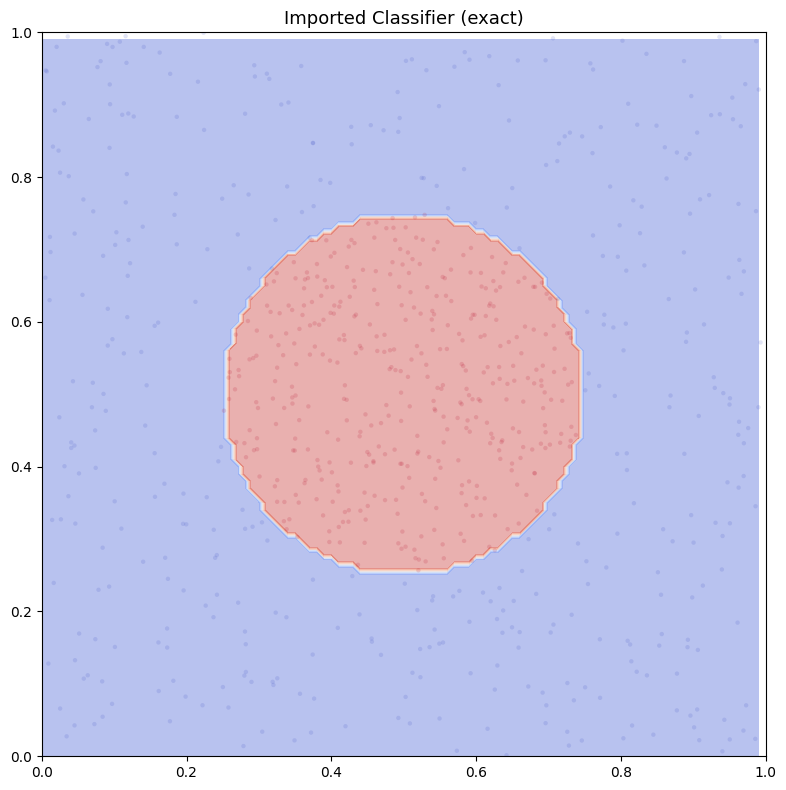

In [4]:
xx, yy = make_meshgrid(np.linspace(0, 1, 300), np.linspace(0, 1, 300))

fig, ax = plt.subplots(figsize=(8, 8))

Z_clf = clf.predict(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
ax.contourf(xx, yy, Z_clf, cmap=plt.cm.coolwarm, alpha=0.4)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=10, edgecolors='none', alpha=0.15)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_title('Imported Classifier (exact)', fontsize=13)

plt.tight_layout()
plt.show()

## LIME explanations on 20 test points (inside and outside the circle)

For each test point we run LIME on the SimplexTree classifier, read its local
linear weights `(w_x, w_y)` and draw them as an arrow. The arrow points in the
direction that LIME says increases the probability of class **+1 (inside)**.

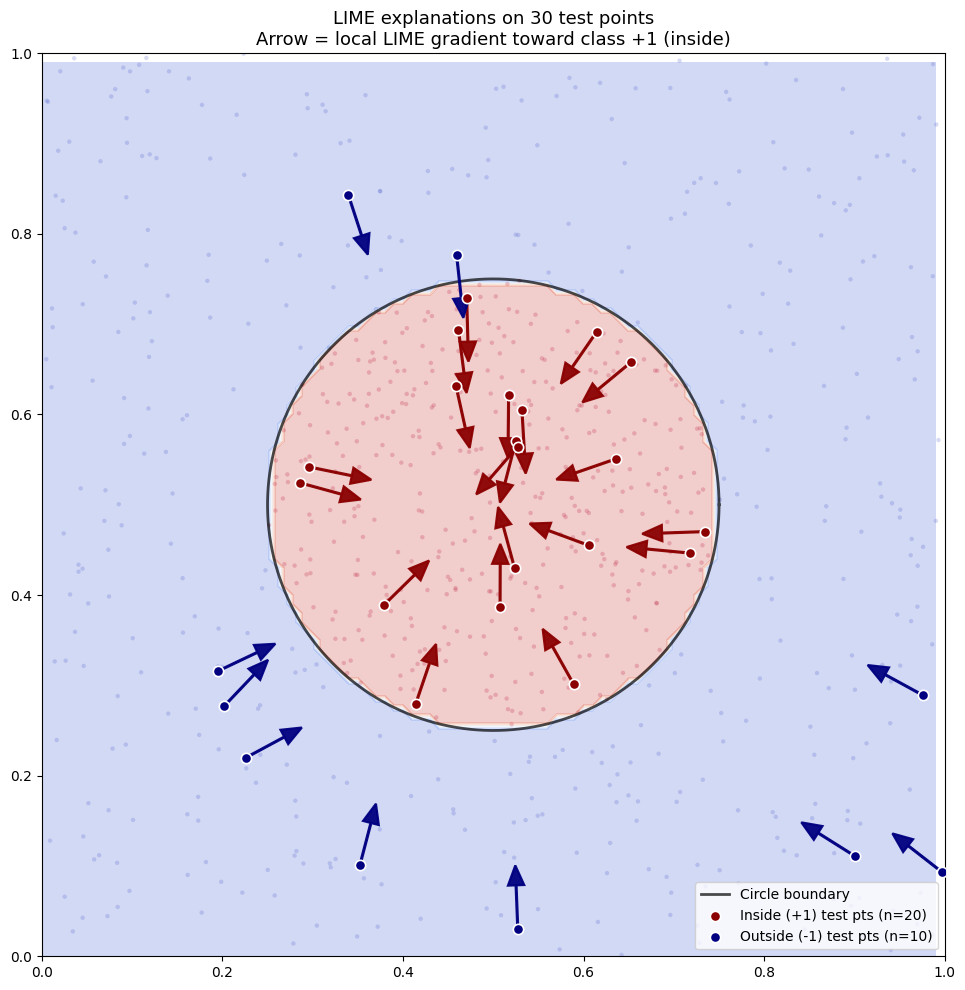

LIME weights per test point (w_x, w_y, direction toward class +1):
  [ 0] (0.471, 0.728)  inside   w=(+0.0010, -0.0348)  |w|=0.0348
  [ 1] (0.532, 0.604)  inside   w=(+0.0000, -0.0002)  |w|=0.0002
  [ 2] (0.735, 0.470)  inside   w=(-0.0472, -0.0016)  |w|=0.0472
  [ 3] (0.461, 0.693)  inside   w=(+0.0008, -0.0064)  |w|=0.0064
  [ 4] (0.636, 0.551)  inside   w=(-0.0006, -0.0002)  |w|=0.0007
  [ 5] (0.525, 0.570)  inside   w=(-0.0000, -0.0000)  |w|=0.0000
  [ 6] (0.653, 0.658)  inside   w=(-0.0197, -0.0162)  |w|=0.0255
  [ 7] (0.379, 0.389)  inside   w=(+0.0012, +0.0012)  |w|=0.0017
  [ 8] (0.717, 0.446)  inside   w=(-0.0294, +0.0028)  |w|=0.0295
  [ 9] (0.459, 0.631)  inside   w=(+0.0002, -0.0009)  |w|=0.0009
  [10] (0.414, 0.279)  inside   w=(+0.0117, +0.0343)  |w|=0.0362
  [11] (0.286, 0.524)  inside   w=(+0.0218, -0.0060)  |w|=0.0226
  [12] (0.507, 0.387)  inside   w=(+0.0000, +0.0002)  |w|=0.0002
  [13] (0.589, 0.301)  inside   w=(-0.0108, +0.0192)  |w|=0.0220
  [14] (0.615, 0.692)  

In [9]:
from lime.lime_tabular import LimeTabularExplainer

N_INSIDE_TEST = 20
N_OUTSIDE_TEST = 10
LIME_NUM_SAMPLES = 2000
SEED = 800

rng = np.random.default_rng(SEED)
inside_test_pts = []
while len(inside_test_pts) < N_INSIDE_TEST:
    cand = rng.uniform(0.0, 1.0, size=2)
    if shape_classify(cand)[0] == 1.0:
        inside_test_pts.append(cand)
outside_test_pts = []
while len(outside_test_pts) < N_OUTSIDE_TEST:
    cand = rng.uniform(0.0, 1.0, size=2)
    if shape_classify(cand)[0] == -1.0:
        outside_test_pts.append(cand)

test_points = np.vstack([np.array(inside_test_pts), np.array(outside_test_pts)])
true_labels = np.concatenate([np.ones(N_INSIDE_TEST), -np.ones(N_OUTSIDE_TEST)])

explainer = LimeTabularExplainer(
    X, feature_names=['x', 'y'],
    class_names=['outside (-1)', 'inside (+1)'],
    mode='classification', random_state=0,
    sample_around_instance=True,
    discretize_continuous=False,
    kernel_width=0.05,
)

arrows = np.zeros_like(test_points)
for i, tp in enumerate(test_points):
    exp = explainer.explain_instance(
        tp,
        clf.predict_proba,
        num_features=2,
        num_samples=LIME_NUM_SAMPLES,
        labels=[1],
    )
    weights = dict(exp.local_exp[1])
    arrows[i, 0] = weights.get(0, 0.0)
    arrows[i, 1] = weights.get(1, 0.0)

magnitudes = np.linalg.norm(arrows, axis=1, keepdims=True)
arrow_directions = arrows / (magnitudes + 1e-12)

fig, ax = plt.subplots(figsize=(10, 10))

Z_clf = clf.predict(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
ax.contourf(xx, yy, Z_clf, cmap=plt.cm.coolwarm, alpha=0.25)

theta = np.linspace(0.0, 2.0 * np.pi, 200)
ax.plot(CIRCLE_CENTER[0] + CIRCLE_RADIUS * np.cos(theta),
        CIRCLE_CENTER[1] + CIRCLE_RADIUS * np.sin(theta),
        'k-', linewidth=2, alpha=0.7, label='Circle boundary')

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm,
           s=10, alpha=0.2, edgecolors='none')

ARROW_LEN = 0.07

for tp, vec, lbl in zip(test_points, arrow_directions, true_labels):
    color = 'darkred' if lbl == 1.0 else 'navy'
    dx, dy = vec[0] * ARROW_LEN, vec[1] * ARROW_LEN
    ax.arrow(tp[0], tp[1], dx, dy,
             head_width=0.018, head_length=0.022,
             fc=color, ec=color, length_includes_head=True,
             linewidth=1.6, zorder=10, alpha=0.95)
    ax.scatter(tp[0], tp[1], c=color, s=55,
               edgecolors='white', linewidths=1.2, zorder=11)

ax.scatter([], [], c='darkred', s=55, edgecolors='white',
           linewidths=1.2, label=f'Inside (+1) test pts (n={N_INSIDE_TEST})')
ax.scatter([], [], c='navy', s=55, edgecolors='white',
           linewidths=1.2, label=f'Outside (-1) test pts (n={N_OUTSIDE_TEST})')

ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_title(f'LIME explanations on {len(test_points)} test points\n'
             f'Arrow = local LIME gradient toward class +1 (inside)',
             fontsize=13)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print('LIME weights per test point (w_x, w_y, direction toward class +1):')
for i, (tp, w, lbl) in enumerate(zip(test_points, arrows, true_labels)):
    region = 'inside ' if lbl == 1.0 else 'outside'
    print(f'  [{i:2d}] ({tp[0]:.3f}, {tp[1]:.3f})  {region}  '
          f'w=({w[0]:+.4f}, {w[1]:+.4f})  |w|={np.linalg.norm(w):.4f}')